# CAMulator Exercises: CESM Tutorial: Summer 2026

#### **CAMulator** is a global, machine-learned autoregressive emulator trained with data from the Community Atmosphere Model. See the version 1 publication here: https://arxiv.org/pdf/2504.06007

The exercises below walk you through running a one-year **control** simulation with prescribed SST, CO2, Sea Ice, and Solar Insolation, in addition to an identical simulation with a +2K perturbation to the SST (everything else same as control). We then investigate some dynamic response to the perturbation. Simulations require a GPU and take approximately 8-10 minutes per annual simulation. 

#### Run the cell below to link to a pre-installed environment. you ONLY NEED TO RUN THIS ONCE. After executing, wait a few moments, and you should then be able to select the `credit_cesm` environment and then execute the remainder of the notebook.

In [ ]:
!conda config --add envs_dirs /glade/work/dgagne/credit_cesm_envs/

In [20]:
import os, sys, glob, subprocess, shlex
from pathlib import Path
import os, pty, select
import yaml
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# >>> EDIT: which year to simulate. Sets inference.single_forecast.start_datetime = <year>-01-01. Valid Years: 1980 - 2014
SIM_YEAR = 1993



# >>> EDIT: the one tutorial config everything else is derived from.
BASE_CONFIG = Path('/glade/work/cbecker/CREDIT-visit/miles-credit/config/gen_2/camulator/camulator_cesm_tutorial_casper.yml')

# Unified CREDIT CLI. `credit rollout` -> credit/applications/rollout_gen2.py.
CREDIT_CLI = 'credit rollout'

# Dotted keys into the config.
SAVE_LOC_KEY    = 'save_loc'
DYN_FORCING_KEY = 'data.source.CESM.variables.dynamic_forcing.path'
OUTPUT_KEY      = 'inference.save_forecast'
FCST_START_KEY  = 'inference.single_forecast.start_datetime'
FCST_LEN_KEY    = 'inference.single_forecast.forecast_length'


def get_by_path(d, dotted):
    for k in dotted.split('.'):
        d = d[k]
    return d

def set_by_path(d, dotted, value):
    keys = dotted.split('.')
    for k in keys[:-1]:
        d = d[k]
    d[keys[-1]] = value

# --- derive paths from the config ------------------------------------------------------
with open(BASE_CONFIG) as f:
    CONF = yaml.safe_load(f)

ROLLOUT_ROOT = Path(os.path.expandvars(get_by_path(CONF, OUTPUT_KEY)))   # .../camulator_tutorial/rollout
RUN_ROOT     = ROLLOUT_ROOT.parent                                       # .../camulator_tutorial
FORCING_ROOT = RUN_ROOT / 'forcing'                                      # perturbed forcing (sibling of rollout)

# Shared, read-only control forcing (a %Y forcing template): read from, never written to.
CONTROL_FORCING = os.path.expandvars(get_by_path(CONF, DYN_FORCING_KEY))

# The chosen simulation year drives start_datetime; length stays whatever the config says.
START_DATETIME  = f'{SIM_YEAR}-01-01T00:00Z'
FORECAST_LENGTH = get_by_path(CONF, FCST_LEN_KEY)   # e.g. '30d' / '365d'

for p in (RUN_ROOT, FORCING_ROOT, ROLLOUT_ROOT):
    p.mkdir(parents=True, exist_ok=True)

print('Config          :', BASE_CONFIG, '(exists:', BASE_CONFIG.exists(), ')')
print('Sim year        :', SIM_YEAR, '->', START_DATETIME, '| length', FORECAST_LENGTH)
print('Output base     :', RUN_ROOT, '(from inference.save_forecast)')
print('  rollout/      :', ROLLOUT_ROOT)
print('  forcing/      :', FORCING_ROOT)
print('Control forcing :', CONTROL_FORCING)

Config          : /glade/work/cbecker/CREDIT-visit/miles-credit/config/gen_2/camulator/camulator_cesm_tutorial_casper.yml (exists: True )
Sim year        : 1995 -> 1995-01-01T00:00Z | length 364d
Output base     : /glade/derecho/scratch/cbecker/camulator_tutorial (from inference.save_forecast)
  rollout/      : /glade/derecho/scratch/cbecker/camulator_tutorial/rollout
  forcing/      : /glade/derecho/scratch/cbecker/camulator_tutorial/forcing
Control forcing : /glade/campaign/cisl/aiml/credit/cesm_exercise/forcing/dynamic_forcing/%Y_forcing.zarr


## 1. Helpers

Address config keys by dotted path, write a per-experiment config copy, list the forecast's years,
perturb the per-year forcing store, drive the CREDIT CLI, and load rollouts back.

In [21]:
def write_config(overrides: dict, out_path: Path) -> Path:
    """Deep-copy BASE_CONFIG, apply {dotted_key: value} overrides, dump to out_path."""
    with open(BASE_CONFIG) as f:
        conf = yaml.safe_load(f)
    for dotted, value in overrides.items():
        set_by_path(conf, dotted, value)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, 'w') as f:
        yaml.safe_dump(conf, f, sort_keys=False)
    return out_path


def forecast_years(start_datetime, length) -> list:
    """Years the forecast window spans (dynamic forcing is one Zarr per year), so we only perturb
    the files actually read. Follows the selected start year + forecast_length."""
    start = pd.Timestamp(start_datetime)
    end = start + pd.Timedelta(length)
    return list(range(start.year, end.year + 1))
    

# Encoding keys inherited from the source Zarr that clash with a fresh (v3) write.
_STRIP_ENC = ("chunks", "preferred_chunks", "compressor", "compressors",
              "filters", "codecs", "serializer")

def perturb_forcing(src_template: str, dst_dir: Path, years, edit_fn) -> str:
    """Write a perturbed copy of the per-year forcing store.

    For each year in `years`, read the control `forcing_%Y.zarr`, apply edit_fn(ds)->ds, and
    write a perturbed `forcing_<year>.zarr` into dst_dir — preserving the `forcing_%Y.zarr`
    naming so the config's `%Y` template still resolves. Time is chunked by 1 (full otherwise)
    to keep the rollout's per-step reads cheap. Returns the dst path *template* (with `%Y`).

    Only the dynamic-forcing fields are touched; the prognostic initial condition still comes
    from the config's (unchanged) prognostic store, so every run starts from the same state.
    """
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    for y in years:
        ds = xr.open_zarr(src_template.replace('%Y', str(y))).load()
        ds = edit_fn(ds)
        ds = ds.chunk({'time': 1, **{d: -1 for d in ds.dims if d != 'time'}})
        for v in ds.variables:                       # drop inherited encoding (chunks/codecs)
            for k in _STRIP_ENC:
                ds[v].encoding.pop(k, None)
        out = dst_dir / f'forcing_{y}.zarr'
        ds.to_zarr(out, mode='w')
        print(f'  wrote {out}')
    return str(dst_dir / 'forcing_%Y.zarr')


# --- the actual interventions (one field each; everything else stays at control) ---
def add_sst(delta_k):
    """Uniform SST warming: SST -> SST + delta_k everywhere, all times."""
    def _edit(ds):
        # ds['SST'] = ds['SST'] + float(delta_k)
        ds['SST'].values = np.where(ds['SST'].values != 283, ds['SST'].values + float(delta_k), ds['SST'].values) # only apply over ocean
        return ds
    return _edit

def scale_co2(factor):
    """CO2 increase: co2vmr_3d -> factor * co2vmr_3d (e.g. 2.0 = doubling)."""
    def _edit(ds):
        ds['co2vmr_3d'] = ds['co2vmr_3d'] * float(factor)
        return ds
    return _edit

In [22]:
def run_credit(config_path: Path, mode='none', procs=4):
    """Invoke the unified CREDIT rollout CLI locally on this (interactive) node.

    `credit rollout -m none` runs in-process on the node's GPU (no PBS submission; that's a
    separate `credit submit --mode rollout` path). Set dry_run=True to just print the command.

    Output is forwarded through a pseudo-terminal (pty) so CREDIT's tqdm bar sees an interactive
    TTY and refreshes a *single* line with carriage returns, instead of printing one line per
    update. This is a subprocess, so you get a clean text bar (not the ipywidgets widget) with no
    changes to CREDIT source.
    """
    cmd = f'{CREDIT_CLI} -c {shlex.quote(str(config_path))} -m {mode} -p {procs}'
    print('$', cmd, flush=True)

    master, slave = pty.openpty()
    proc = subprocess.Popen(shlex.split(cmd), stdout=slave, stderr=slave, close_fds=True)
    os.close(slave)  # parent only reads the master end
    try:
        while True:
            if select.select([master], [], [], 0.1)[0]:
                try:
                    data = os.read(master, 1024)
                except OSError:  # master closes when the child exits
                    break
                if not data:
                    break
                sys.stdout.write(data.decode(errors='replace'))
                sys.stdout.flush()
            elif proc.poll() is not None:
                break
    finally:
        os.close(master)
        proc.wait()

    if proc.returncode != 0:
        raise RuntimeError(f'{CREDIT_CLI} exited with code {proc.returncode}')
    return proc.returncode

In [23]:
def load_rollout(output_dir, year=None, variables=None):
    """Open the NetCDF rollout (monthly files per the config) as one time-ordered dataset.

    year:      keep only files for that valid year (files are named YYYY-MM.nc) — use when a run
               spans more than one year so you don't open the whole rollout.
    variables: subset to these (those that exist) before returning, so a later .load() reads only
               what you actually need.
    """
    files = sorted(glob.glob(os.path.join(str(output_dir), '**', '*.nc'), recursive=True))
    if year is not None:
        files = [f for f in files if os.path.basename(f).startswith(f'{year}')]
    if not files:
        raise FileNotFoundError(f'No .nc files (year={year}) under {output_dir}')
    ds = xr.open_mfdataset(files, combine='by_coords')
    if variables is not None:
        present = [v for v in variables if v in ds.variables]
        missing = set(variables) - set(present)
        if missing:
            print(f'  (note: not in output, skipped: {sorted(missing)})')
        ds = ds[present]
    return ds

def global_mean(da, lat_name='latitude'):
    """Cosine-latitude-weighted global mean, collapsing lat/lon."""
    lat = da[lat_name]
    w = np.cos(np.deg2rad(lat))
    lon_name = 'lon' if 'lon' in da.dims else [d for d in da.dims if d not in (lat_name,)][ -1]
    return da.weighted(w).mean(dim=[lat_name, lon_name])

## 2. Control run

The baseline everything is differenced against. Uses the shared control forcing **untouched** —
we only redirect the output to `rollout/control/`.

In [26]:
EXPERIMENT = 'control'
control_out = ROLLOUT_ROOT / EXPERIMENT

# Control forcing is left as-is (shared, read-only); we redirect output and set the sim year.
control_cfg = write_config(
    overrides={
        OUTPUT_KEY: str(control_out) + '/',
        FCST_START_KEY: START_DATETIME,
    },
    out_path=control_out / 'config.yml',
)

run_credit(control_cfg)

## 3. Experiment A — uniform SST warming (+2 K)

**Intervention:** `SST +2K` over the ocean, all times (CO2/ice/solar untouched).

**Expectation:** a moister atmosphere (precipitable water ≈ +7%/K) but weaker precip response(≈ +1–3%/K). 

In [22]:
EXPERIMENT = 'sst_plus2K'
DELTA_SST = 2.0  # K
years = forecast_years(START_DATETIME, FORECAST_LENGTH)
print('Perturbing forcing years:', years)

# 1) perturbed forcing copy -> forcing/<experiment>/forcing_%Y.zarr
sst_forcing = perturb_forcing(
    src_template=CONTROL_FORCING,
    dst_dir=FORCING_ROOT / EXPERIMENT,
    years=years,
    edit_fn=add_sst(DELTA_SST),
)

# 2) config copy: perturbed forcing, output dir, and the selected sim year
sst_cfg = write_config(
    overrides={
        DYN_FORCING_KEY: sst_forcing,
        OUTPUT_KEY: str(ROLLOUT_ROOT / EXPERIMENT) + '/',
        FCST_START_KEY: START_DATETIME,
    },
    out_path=ROLLOUT_ROOT / EXPERIMENT / 'config.yml',
)

# 3) run
run_credit(sst_cfg)

Perturbing forcing years: [1995]


/glade/work/cbecker/conda-envs/credit-aiml/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  wrote /glade/derecho/scratch/cbecker/camulator_tutorial/forcing/sst_plus2K/forcing_1995.zarr
$ credit rollout -c /glade/derecho/scratch/cbecker/camulator_tutorial/rollout/sst_plus2K/config.yml -m none -p 4
INFO:credit.datasets.schema:Loading channel schema from /glade/campaign/cisl/aiml/credit/cesm_exercise/channel_schema.yaml
<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
INFO:credit.models:Loading the CAMulator model with a conv decoder head and skip connections ...
INFO:credit.models.base_model:Loading a model with pre-trained weights from path /glade/campaign/cisl/aiml/credit/cesm_exercise/checkpoint.pt
INFO:credit.models.camulator:Adding spectral norm to all conv and linear layers
INFO:credit.models.checkpoint:All keys matched successfully
INFO:credit.datasets.multi_source:MultiSourceDataset: registered dataset 'CESM' with class 'LocalDataset'
INFO:rollout_gen2:Ra

0

## 4. Compare

Load **once** into memory — only the year and variables the plots + CC diagnostic need.

In [25]:
%%time
LOAD_YEAR = SIM_YEAR                    # which simulated year to analyze
LIGHT_VARS  = ['TREFHT', 'PRECT', 'PS', 'Qtot']       # small 2-D fields (plots + precip) -> load into memory
STREAM_VARS = []            # used only by the PW integral -> keep LAZY so it streams
NEEDED_VARS = LIGHT_VARS + STREAM_VARS

ctrl = load_rollout(ROLLOUT_ROOT / 'control',    year=LOAD_YEAR, variables=NEEDED_VARS).load()
sst  = load_rollout(ROLLOUT_ROOT / 'sst_plus2K', year=LOAD_YEAR, variables=NEEDED_VARS).load()

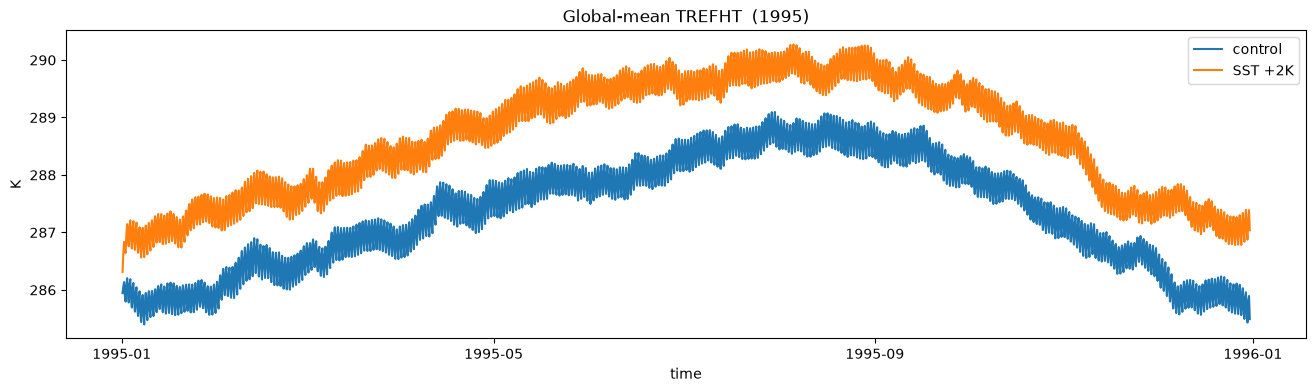

In [8]:
VAR = 'TREFHT'  # 2 m temperature (prognostic)

# --- global-mean time series -------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 4))
for ds, label in [(ctrl, 'control'), (sst, 'SST +2K')]:
    global_mean(ds[VAR]).plot(ax=ax, label=label)
ax.set_title(f'Global-mean {VAR}  ({LOAD_YEAR})')
ax.set_ylabel('K'); ax.legend(); plt.show()

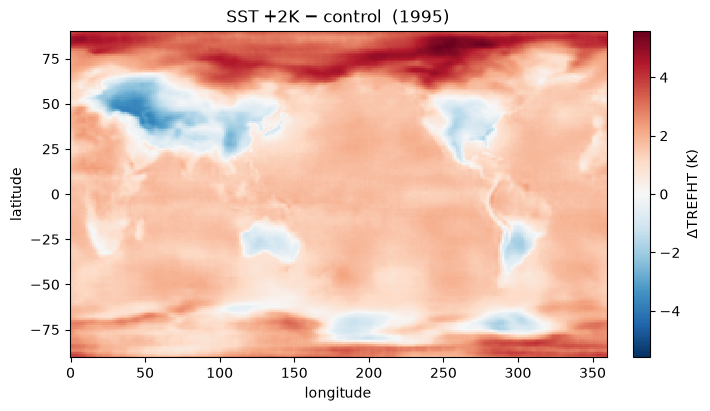

In [9]:
VAR = 'TREFHT'  # 2 m temperature (prognostic)

# --- annual-mean difference map (SST +2K − control) --------------------------
diff = sst[VAR].mean('time') - ctrl[VAR].mean('time')
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
diff.plot(ax=ax, cmap='RdBu_r', center=0, cbar_kwargs={'label': f'Δ{VAR} (K)'})
ax.set_title(f'SST +2K − control  ({LOAD_YEAR})')
plt.show()

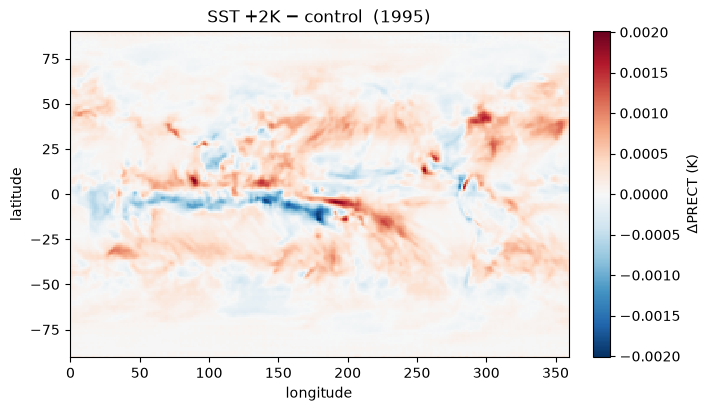

In [10]:
VAR = 'PRECT'  # 2 m temperature (prognostic)

# --- annual-mean difference map (SST +2K − control) --------------------------
diff = sst[VAR].mean('time') - ctrl[VAR].mean('time')
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
diff.plot(ax=ax, cmap='RdBu_r', center=0, cbar_kwargs={'label': f'Δ{VAR} (K)'})
ax.set_title(f'SST +2K − control  ({LOAD_YEAR})')
plt.show()

#### Clausius–Clapeyron water scaling (SST experiment)

Two numbers from the SST-warming run: column **water vapor** (precipitable water, from `Qtot`) should
rise ~7 %/K — the thermodynamic Clausius–Clapeyron rate — while **precipitation** (`PRECT`) rises far
slower, ~1–3 %/K, because it's constrained by atmospheric energetics rather than moisture supply. The
gap between those two numbers is the headline result.

Method: paired `pert − ctrl` (cancels common model drift), drop a spin-up, cosine-latitude-weighted
global mean, time-average, normalize by the *actual* global-mean warming (`ΔTREFHT`, < the 2 K imposed
over ocean). Precipitable water is a **mass-weighted** vertical integral of `Qtot`, **not** a plain
level-sum. Reuses the in-memory `ctrl` / `sst` from the Compare load — no extra reads.


In [12]:
# Hybrid-sigma coefficients from the mass_fixer's statics file (config-derived), loaded once as
# float32 so the column integral stays float32 (avoids a float64 memory blow-up).
STATICS_PHYSICS = get_by_path(CONF, 'postblocks.per_step.mass_fixer.args.save_loc_physics')
_ST = xr.open_dataset(STATICS_PHYSICS)

_HYAI = _ST['hyai'].astype('float32').load()          # interface hybrid coeffs (length nlev+1)
_HYBI = _ST['hybi'].astype('float32').load()
_ILEV = _HYAI.dims[0]                                 # interface dim name, auto-detected (e.g. 'ilev')
_G  = 9.80665                                         # Gravity
_P0 = 100000.0   # Pa; CAM ref pressure


def precipitable_water(ds, q_var='Qtot', ps_var='PS', lev='level'):
    """Mass-weighted column water: PW = (1/g) Σ q_k Δp_k  [kg/m² == mm].

    Δp from the hybrid interfaces p = hyai*P0 + hybi*PS. NOT a plain level-sum. Stays float32 and,
    if Qtot/PS are lazy, stays lazy — so the reduction streams over the 3-D cube (bounded memory).
    """
    p_int = _HYAI * _P0 + _HYBI * ds[ps_var].astype('float32')     # (..., ilev)
    dp = abs(p_int.diff(_ILEV)).rename({_ILEV: lev}).transpose('time', 'level', ...)
    if lev in ds.coords:
        dp = dp.assign_coords({lev: ds[lev].values})
    return (ds[q_var].astype('float32') * dp).sum(lev) / _G


SPINUP_DAYS = 30   # discard atmospheric adjustment (~water-vapor residence time)

def _after_spinup(da):
    return da.isel(time=slice(int(SPINUP_DAYS * 24 / 6), None))    # 6-hourly steps


def scaling_per_K(pert, ctrl):
    """Paired %/K for precip (PRECT) and precipitable water (Qtot column), normalized by the actual
    global-mean warming ΔT. Spin-up is sliced up front so the heavy integral runs on less data;
    differencing pert-ctrl cancels common model drift."""
    p, c = _after_spinup(pert), _after_spinup(ctrl)
    def gm(da): return float(global_mean(da).mean('time'))        # triggers the streaming compute
    dT = gm(p['TREFHT']) - gm(c['TREFHT'])
    def pct(fp, fc): return (gm(fp) - gm(fc)) / gm(fc) * 100
    return {
        'dT': dT,
        'precip_pct_per_K': pct(p['PRECT'], c['PRECT']) / dT,
        'pw_pct_per_K':     pct(precipitable_water(p), precipitable_water(c)) / dT,
    }

In [25]:
%%time
# Clausius–Clapeyron scaling for the SST-warming experiment (sst vs ctrl).
res = scaling_per_K(sst, ctrl)
n_avg = sst.time.size - int(SPINUP_DAYS * 24 / 6)
print(f"ΔT (global-mean TREFHT)    : {res['dT']:+.2f} K")
print(f"Precipitation scaling      : {res['precip_pct_per_K']:+.1f} %/K   (expect ~1-3)")
print(f"Precipitable-water scaling : {res['pw_pct_per_K']:+.1f} %/K   (expect ~7, Clausius-Clapeyron)")
print(f"(spin-up dropped: {SPINUP_DAYS} d | steps averaged: {n_avg})")

ΔT (global-mean TREFHT)    : +1.29 K
Precipitation scaling      : +11.3 %/K   (expect ~1-3)
Precipitable-water scaling : +8.7 %/K   (expect ~7, Clausius-Clapeyron)
(spin-up dropped: 30 d | steps averaged: 1336)
CPU times: user 27.5 s, sys: 34.5 s, total: 1min 1s
Wall time: 2min 27s


## 6. Warming structure & precipitation extremes

Three diagnostics squeezed from the existing control vs SST+2K runs. Spin-up (first month) is dropped.

1. **Zonal-mean warming** — `ΔTREFHT` vs latitude: a uniform +2 K SST does **not** give uniform
   surface warming (structure / polar amplification).
2. **Land vs ocean contrast** — land warms *more* than ocean even though SST is the prescribed knob;
   the land/ocean ratio (~1.4–1.6 in obs) is a robust warming fingerprint.
3. **Precipitation extremes** — pooled 6-hourly `PRECT` distributions: the mean rises slowly (~2 %/K)
   while the high percentiles rise ~Clausius–Clapeyron (~7 %/K). The tail moves faster than the mean.

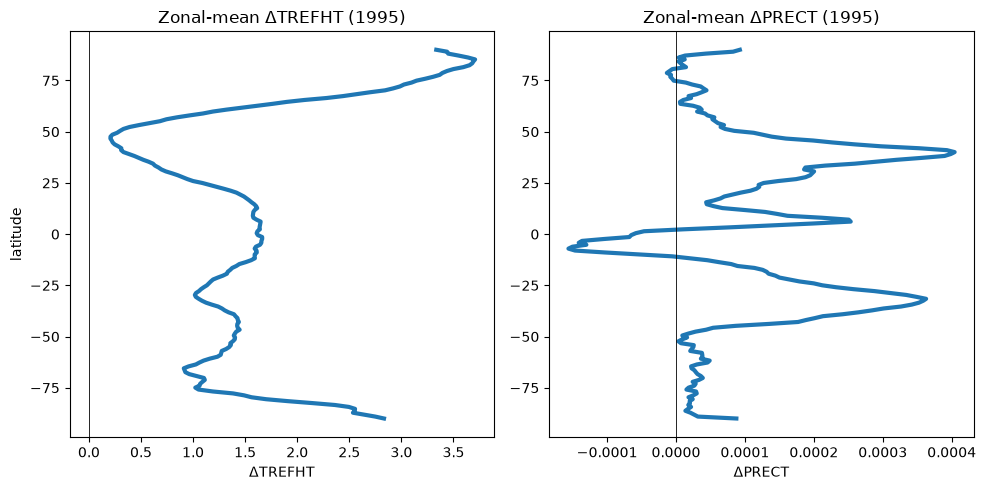

CPU times: user 857 ms, sys: 268 ms, total: 1.13 s
Wall time: 1.12 s


In [14]:
%%time
import matplotlib.pyplot as plt

# Define the two variables you want to plot side-by-side
variables = ['TREFHT', 'PRECT'] 

# Handle dimension names dynamically
LAT = 'latitude' if 'latitude' in ctrl.dims else 'lat'
LON = 'longitude' if 'longitude' in ctrl.dims else 'lon'

# Create a 1x2 grid of subplots with a wider figure size
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Loop through the variables and their corresponding axes
for i, var in enumerate(variables):
    ax = axes[i]
    
    # Calculate the time-mean anomaly, then the zonal mean
    diff_map = (_after_spinup(sst[var]).mean('time') 
              - _after_spinup(ctrl[var]).mean('time'))     # (lat, lon)
    diff_zonal = diff_map.mean(LON)                        # (lat,)

    # Plot on the specific axis
    diff_zonal.plot(ax=ax, y=LAT, linewidth=3)
    
    # Add the zero reference line
    ax.axvline(0, color='k', lw=0.6)
    
    # Dynamically label the x-axis and title based on the variable
    ax.set_xlabel(f'Δ{var}')
    ax.set_title(f'Zonal-mean Δ{var} ({LOAD_YEAR})')
    
    # Only label the y-axis (latitude) on the leftmost plot to keep it clean
    if i == 0:
        ax.set_ylabel('latitude')
    else:
        ax.set_ylabel('')

# Automatically adjust spacing so the plots don't overlap
plt.tight_layout()
plt.show()

In [48]:
# #2  Land vs ocean warming contrast. Land mask from the static LANDM_COSLAT (config-derived).
STATIC_PATH = os.path.expandvars(get_by_path(CONF, 'data.source.CESM.variables.static.path'))
_landm = xr.open_dataset(STATIC_PATH)['LANDM_COSLAT'].squeeze()
is_land = xr.DataArray(np.asarray(_landm.values) > 0.8, dims=(LAT, LON),
                       coords={LAT: ctrl[LAT], LON: ctrl[LON]})
_coslat = np.cos(np.deg2rad(ctrl[LAT]))
def _region_mean(da, region):
    return float(da.weighted((_coslat * region).fillna(0)).mean([LAT, LON]))

dT_land  = _region_mean(dT_map, is_land)      # dT_map from cell #1
dT_ocean = _region_mean(dT_map, ~is_land)
print(f'ΔTREFHT land   = {dT_land:+.2f} K')
print(f'ΔTREFHT ocean  = {dT_ocean:+.2f} K')


ΔTREFHT land   = +0.81 K
ΔTREFHT ocean  = +1.57 K


 pctile   control    SST+2K   change
     50      0.51      0.69    35.2%
     90      8.23      9.24    12.3%
     99     38.30     43.16    12.7%
   99.9     80.91     95.06    17.5%


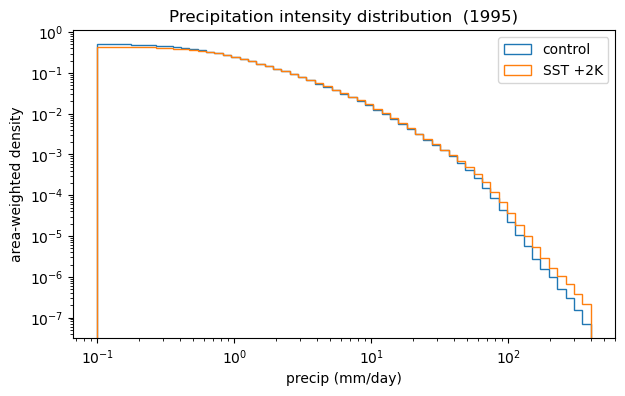

In [30]:
def _precip_and_weights(ds):
    da = _after_spinup(ds['PRECT']) * 4000.0                  # mm/day, (time, lat, lon)
    w  = np.cos(np.deg2rad(da[LAT])).broadcast_like(da)
    return da.values.ravel(), w.values.ravel()

def _wq(x, w, q):                                            # area-weighted percentile(s)
    i = np.argsort(x); x, w = x[i], w[i]
    c = np.cumsum(w) - 0.5 * w
    return np.interp(np.atleast_1d(q) / 100 * w.sum(), c, x)

p_ctrl, w_ctrl = _precip_and_weights(ctrl)
p_sst,  w_sst  = _precip_and_weights(sst)

print(f"{'pctile':>7} {'control':>9} {'SST+2K':>9} {'change':>8}")
for q in (50, 90, 99, 99.9):
    a, b = _wq(p_ctrl, w_ctrl, q)[0], _wq(p_sst, w_sst, q)[0]
    print(f"{q:>7} {a:>9.2f} {b:>9.2f} {(b - a) / a * 100:>7.1f}%")

# area-weighted intensity distribution of wet hours (log-log to expose the tail)
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.logspace(-1, 2.6, 60)                             # ~0.1 .. ~400 mm/day
for p, w, label in [(p_ctrl, w_ctrl, 'control'), (p_sst, w_sst, 'SST +2K')]:
    wet = p > 0.1
    ax.hist(p[wet], bins=bins, weights=w[wet], histtype='step', density=True, label=label)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('precip (mm/day)'); ax.set_ylabel('area-weighted density')
ax.set_title(f'Precipitation intensity distribution  ({LOAD_YEAR})')
ax.legend(); plt.show()